In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [4]:
# Load Fashion MNIST data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Normalize pixel values to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension for CNN
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("CNN training shape:", X_train.shape)
print("CNN test shape:", X_test.shape)

Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)
CNN training shape: (60000, 28, 28, 1)
CNN test shape: (10000, 28, 28, 1)


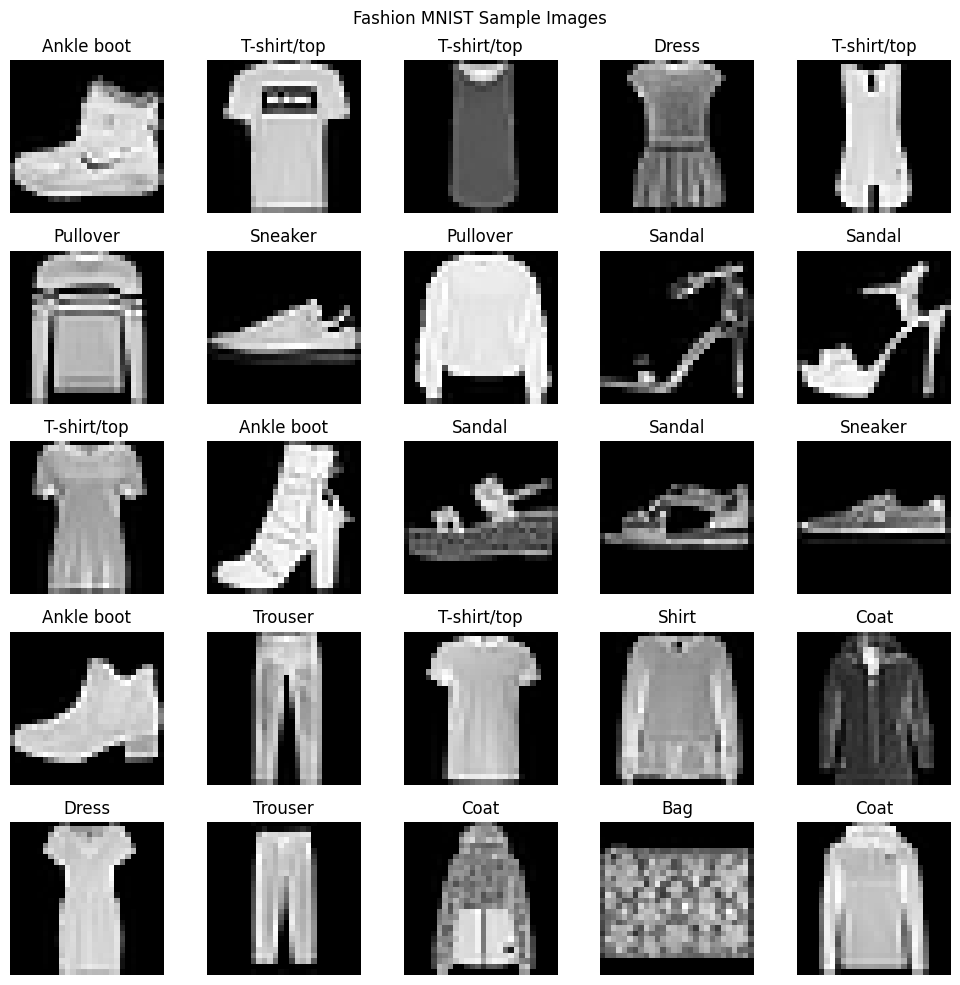

In [5]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Fashion MNIST Sample Images")
plt.tight_layout()
plt.show()

In [6]:
def plot_training_curves(history, title):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"\n{model_name} Test Evaluation")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    return accuracy, precision, recall, f1

# Baseline CNN

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8528 - loss: 0.4226 - val_accuracy: 0.8825 - val_loss: 0.3281
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8962 - loss: 0.2892 - val_accuracy: 0.8972 - val_loss: 0.2937
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9110 - loss: 0.2468 - val_accuracy: 0.9010 - val_loss: 0.2802
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9220 - loss: 0.2147 - val_accuracy: 0.9010 - val_loss: 0.2773
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9326 - loss: 0.1876 - val_accuracy: 0.9028 - val_loss: 0.2809


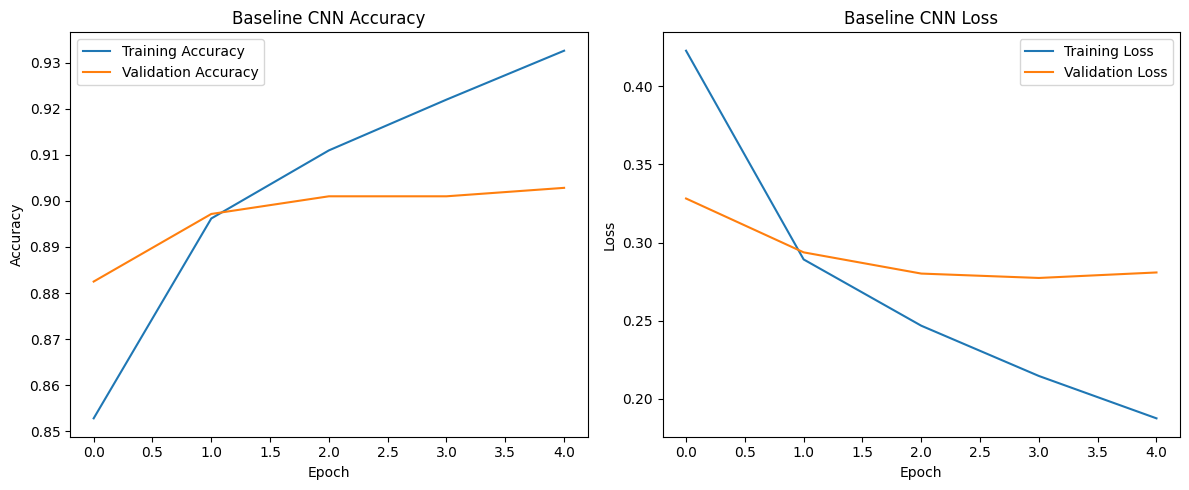

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Baseline CNN Test Evaluation
Accuracy:  0.9036
Precision: 0.9046
Recall:    0.9036
F1 Score:  0.9013


In [8]:
tf.random.set_seed(42)

baseline_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

plot_training_curves(baseline_history, "Baseline CNN")

baseline_results = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    "Baseline CNN"
)

The baseline CNN used one convolutional layer, max pooling, and one dense hidden layer. This model established a reference point for later experiments. 

It achieved strong overall classification performance on the Fashion MNIST dataset, reaching a test accuracy of approximately 90.4%. Both training and validation accuracy steadily improved across epochs, while training and validation loss decreased consistently.

However, the training curves began improving faster than the validation curves during later epochs. Validation loss also started to flatten while training loss continued decreasing, suggesting the beginning of mild overfitting.

Overall, the baseline CNN provided a strong reference point for later experiments involving regularization, larger model capacity, and systematic hyperparameter tuning.

# Round 1 : Add Dropout

Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - accuracy: 0.8216 - loss: 0.5159 - val_accuracy: 0.8785 - val_loss: 0.3343
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.8764 - loss: 0.3485 - val_accuracy: 0.8898 - val_loss: 0.3014
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.8912 - loss: 0.3056 - val_accuracy: 0.8958 - val_loss: 0.2825
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9006 - loss: 0.2762 - val_accuracy: 0.9058 - val_loss: 0.2660
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - accuracy: 0.9068 - loss: 0.2576 - val_accuracy: 0.9047 - val_loss: 0.2602
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9121 - loss: 0.2399 - val_accuracy: 0.9092 - val_loss: 0.2622
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9163 - loss: 0.2239 - val_accuracy: 0.9102 - val_loss: 0.2555
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.9203 - loss: 0

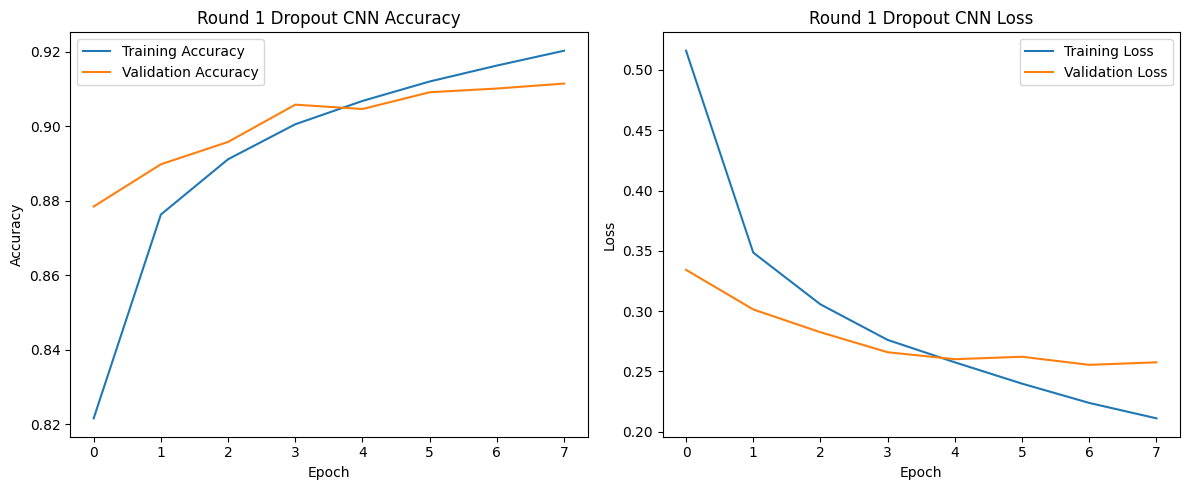

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

Round 1 Dropout CNN Test Evaluation
Accuracy:  0.9052
Precision: 0.9055
Recall:    0.9052
F1 Score:  0.9036


In [10]:
tf.random.set_seed(42)

dropout_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

dropout_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dropout_history = dropout_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

plot_training_curves(dropout_history, "Round 1 Dropout CNN")

dropout_results = evaluate_model(
    dropout_model,
    X_test,
    y_test,
    "Round 1 Dropout CNN"
)

Round 1 added dropout regularization after the dense hidden layer to reduce overfitting and improve model generalization.

Compared to the baseline CNN, the gap between training and validation accuracy became smaller, suggesting that the model relied less on memorizing training examples. Validation loss also remained more stable throughout training, while validation accuracy improved slightly.

The dropout model achieved a test accuracy of approximately 90.5%, improving slightly over the baseline CNN. Overall, dropout regularization helped improve generalization performance while reducing overfitting behavior.

# Round 2 : Larger CNN Architecture


Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - accuracy: 0.8517 - loss: 0.4113 - val_accuracy: 0.8880 - val_loss: 0.3054
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.9001 - loss: 0.2746 - val_accuracy: 0.8955 - val_loss: 0.2828
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9154 - loss: 0.2281 - val_accuracy: 0.9052 - val_loss: 0.2681
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.9299 - loss: 0.1904 - val_accuracy: 0.9058 - val_loss: 0.2702
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.9423 - loss: 0.1585 - val_accuracy: 0.9095 - val_loss: 0.2674
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.9531 - loss: 0.1294 - val_accuracy: 0.9115 - val_loss: 0.2851
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.9617 - loss: 0.1074 - val_accuracy: 0.9128 - val_loss: 0.3092
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9694 - loss: 0

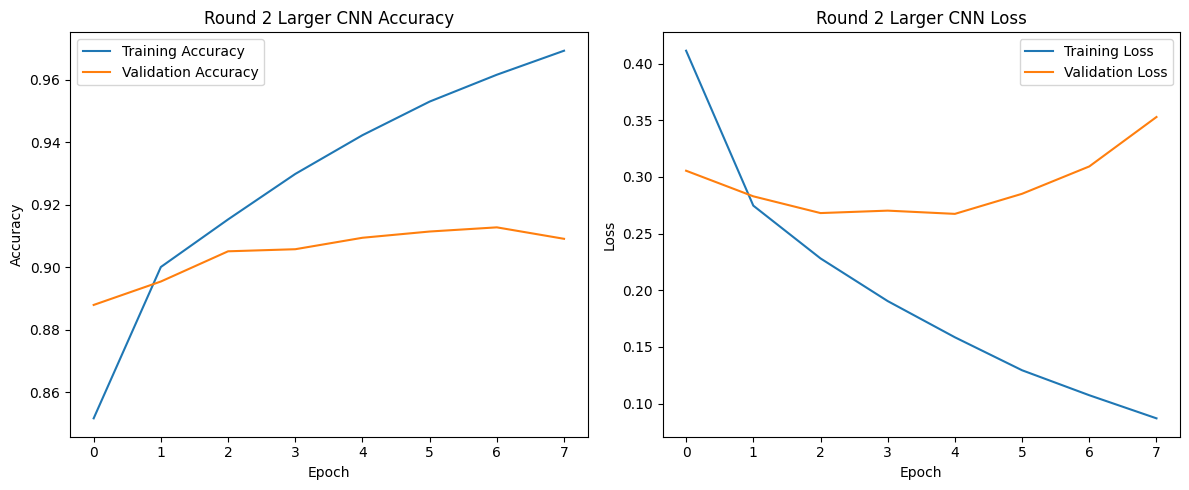

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Round 2 Larger CNN Test Evaluation
Accuracy:  0.9068
Precision: 0.9094
Recall:    0.9068
F1 Score:  0.9053


In [11]:
tf.random.set_seed(42)

larger_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

larger_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

larger_history = larger_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

plot_training_curves(larger_history, "Round 2 Larger CNN")

larger_results = evaluate_model(
    larger_model,
    X_test,
    y_test,
    "Round 2 Larger CNN"
)

Round 2 increased the CNN model capacity by adding an additional convolutional layer and a larger dense hidden layer. The goal was to test whether a deeper architecture would improve feature extraction and classification performance.

Among the manually designed models, the larger CNN achieved the highest test accuracy. However, it also showed the clearest signs of overfitting, with training accuracy continuing to rise while validation loss increased.

Compared to the previous dropout model, the larger CNN produced weaker generalization performance despite its increased complexity. The test accuracy remained similar overall, suggesting diminishing returns from simply increasing CNN depth and model capacity.

This experiment demonstrated that larger architectures can memorize training data more easily without necessarily improving performance on unseen test images.

# Round 3 : Batch Normalization CNN


Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 54s 31ms/step - accuracy: 0.8574 - loss: 0.3989 - val_accuracy: 0.8870 - val_loss: 0.3082
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9035 - loss: 0.2658 - val_accuracy: 0.9072 - val_loss: 0.2619
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 50s 30ms/step - accuracy: 0.9182 - loss: 0.2230 - val_accuracy: 0.9068 - val_loss: 0.2625
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9297 - loss: 0.1921 - val_accuracy: 0.9100 - val_loss: 0.2523
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9408 - loss: 0.1662 - val_accuracy: 0.9012 - val_loss: 0.2828
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9482 - loss: 0.1436 - val_accuracy: 0.8975 - val_loss: 0.3038
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9548 - loss: 0.1231 - val_accuracy: 0.9102 - val_loss: 0.2860
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9596 - loss: 0

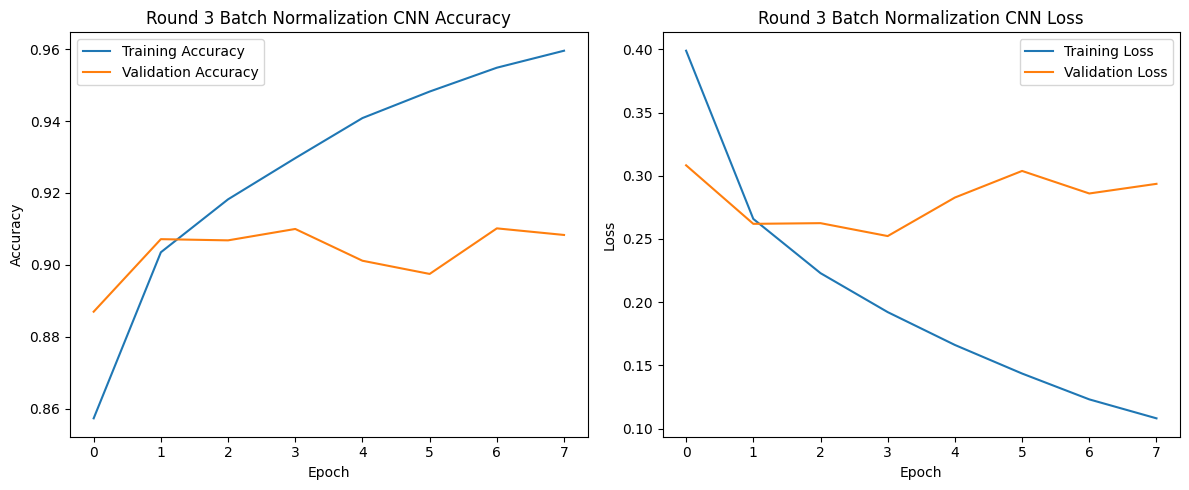

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Round 3 Batch Normalization CNN Test Evaluation
Accuracy:  0.9052
Precision: 0.9059
Recall:    0.9052
F1 Score:  0.9035


In [12]:
tf.random.set_seed(42)

batchnorm_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

batchnorm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

batchnorm_history = batchnorm_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

plot_training_curves(batchnorm_history, "Round 3 Batch Normalization CNN")

batchnorm_results = evaluate_model(
    batchnorm_model,
    X_test,
    y_test,
    "Round 3 Batch Normalization CNN"
)

Round 3 introduced batch normalization layers after each convolutional layer to improve training stability and normalize intermediate feature distributions during learning.

Compared to the previous larger CNN model, the training curves became smoother and optimization behavior appeared more stable overall. However, validation accuracy improved only slightly, while validation loss still began increasing during later epochs.

Although batch normalization helped stabilize training, the model continued to show signs of overfitting as training accuracy kept increasing while validation performance plateaued. The test accuracy remained close to the dropout model but was slightly lower than the larger CNN model.

This experiment suggests that batch normalization improved optimization stability more effectively than overall generalization performance for this Fashion MNIST classification task.

# Round 4 : L2 Regularization + Dropout + EarlyStopping

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 76s 44ms/step - accuracy: 0.8221 - loss: 0.6091 - val_accuracy: 0.8615 - val_loss: 0.4443
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.8724 - loss: 0.4432 - val_accuracy: 0.8888 - val_loss: 0.3838
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 88s 52ms/step - accuracy: 0.8850 - loss: 0.4081 - val_accuracy: 0.8912 - val_loss: 0.3792
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 111s 34ms/step - accuracy: 0.8937 - loss: 0.3837 - val_accuracy: 0.9028 - val_loss: 0.3661
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.8989 - loss: 0.3736 - val_accuracy: 0.9087 - val_loss: 0.3423
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - accuracy: 0.9021 - loss: 0.3630 - val_accuracy: 0.9080 - val_loss: 0.3451
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.9049 - loss: 0.3570 - val_accuracy: 0.9053 - val_loss: 0.3583
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 29ms/step - accuracy: 0.9071 

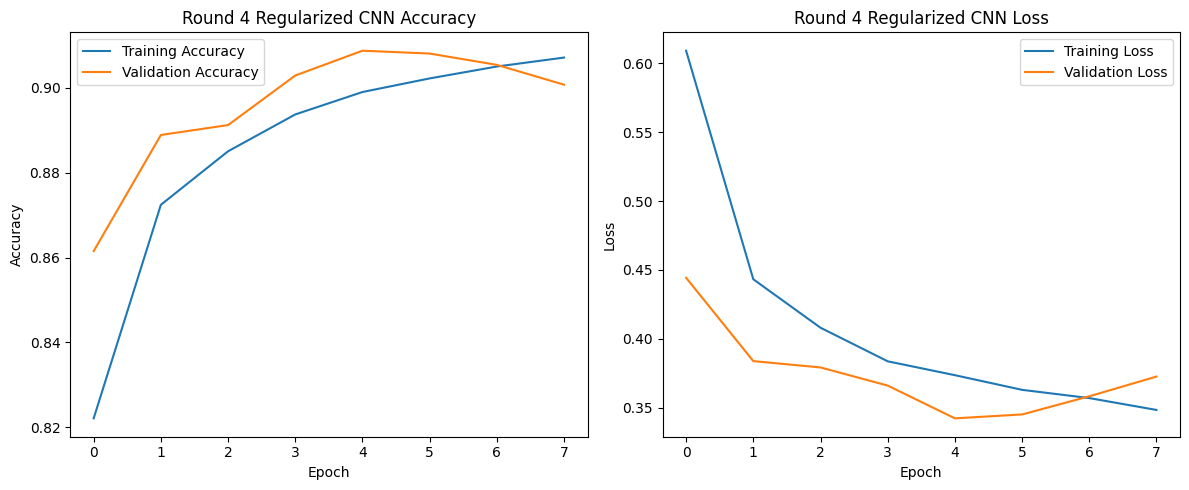

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Round 4 Regularized CNN Test Evaluation
Accuracy:  0.9027
Precision: 0.9024
Recall:    0.9027
F1 Score:  0.9012


In [14]:
tf.random.set_seed(42)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

regularized_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(0.0005)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(0.0005)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.0005)
    ),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

regularized_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

regularized_history = regularized_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

plot_training_curves(regularized_history, "Round 4 Regularized CNN")

regularized_results = evaluate_model(
    regularized_model,
    X_test,
    y_test,
    "Round 4 Regularized CNN"
)

# Results Comparison

Round 4 combined multiple regularization strategies, including L2 regularization, dropout, batch normalization, and early stopping. The goal was to reduce overfitting while maintaining strong classification performance.

Compared to the previous models, the training and validation curves remained much closer together throughout training, suggesting improved generalization behavior and more stable optimization. Validation loss also remained relatively stable across epochs without the sharp increases observed in earlier larger CNN experiments.

Although the final test accuracy was slightly lower than the earlier dropout-only model, the regularized CNN produced healthier training behavior overall with reduced overfitting and more consistent validation performance.

This experiment demonstrated that combining multiple regularization methods can improve model stability and generalization, even when the final accuracy gains are relatively modest.

In [15]:
results_df = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Round 1: Dropout",
        "Round 2: Larger CNN",
        "Round 3: BatchNorm",
        "Round 4: L2 + Dropout + EarlyStopping"
    ],
    "Accuracy": [
        baseline_results[0],
        dropout_results[0],
        larger_results[0],
        batchnorm_results[0],
        regularized_results[0]
    ],
    "Precision": [
        baseline_results[1],
        dropout_results[1],
        larger_results[1],
        batchnorm_results[1],
        regularized_results[1]
    ],
    "Recall": [
        baseline_results[2],
        dropout_results[2],
        larger_results[2],
        batchnorm_results[2],
        regularized_results[2]
    ],
    "F1 Score": [
        baseline_results[3],
        dropout_results[3],
        larger_results[3],
        batchnorm_results[3],
        regularized_results[3]
    ]
})

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline CNN,0.9036,0.904637,0.9036,0.901280
1,Round 1: Dropout,0.9052,0.905480,0.9052,0.903622
2,Round 2: Larger CNN,0.9068,0.909428,0.9068,0.905259
3,Round 3: BatchNorm,0.9052,0.905882,0.9052,0.903453
4,Round 4: L2 + Dropout + EarlyStopping,0.9027,0.902365,0.9027,0.901150


The larger CNN achieved the highest overall test accuracy, but also showed the clearest signs of overfitting. In contrast, the regularized CNN models produced healthier training behavior with smaller train-validation gaps and more stable validation loss curves.

These experiments demonstrated the tradeoff between maximizing raw predictive performance and improving model generalization stability. Increasing model capacity slightly improved classification accuracy, while regularization methods such as dropout, batch normalization, L2 regularization, and early stopping helped reduce overfitting and stabilize optimization behavior.

In [ ]:
%pip install optuna

# Optuna Final Tuning

In [16]:
import optuna
from tensorflow.keras.optimizers import Adam

def objective(trial):

    tf.keras.backend.clear_session()

    filters_1 = trial.suggest_categorical("filters_1", [16, 32, 64])
    filters_2 = trial.suggest_categorical("filters_2", [32, 64, 128])
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5)
    l2_rate = trial.suggest_float("l2_rate", 1e-5, 1e-3, log=True)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(
            filters_1,
            (3, 3),
            padding="same",
            kernel_regularizer=regularizers.l2(l2_rate)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            filters_2,
            (3, 3),
            padding="same",
            kernel_regularizer=regularizers.l2(l2_rate)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(
            dense_units,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_rate)
        ),
        layers.Dropout(dropout_rate),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=15,
        batch_size=batch_size,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    best_val_acc = max(history.history["val_accuracy"])

    return best_val_acc


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("Best trial:")
print(study.best_trial.params)
print("Best validation accuracy:", study.best_value)

[I 2026-05-28 13:59:35,463] A new study created in memory with name: no-name-bf322467-f67e-4dbe-8f3e-b63581e861aa


[I 2026-05-28 14:18:12,368] Trial 0 finished with value: 0.9235000014305115 and parameters: {'filters_1': 32, 'filters_2': 128, 'dense_units': 64, 'dropout_rate': 0.2166911135243307, 'l2_rate': 4.175170742574219e-05, 'learning_rate': 0.0002177113171443027, 'batch_size': 32}. Best is trial 0 with value: 0.9235000014305115.
[I 2026-05-28 14:37:44,019] Trial 1 finished with value: 0.9213333129882812 and parameters: {'filters_1': 64, 'filters_2': 64, 'dense_units': 64, 'dropout_rate': 0.4341599473746943, 'l2_rate': 0.0009367139981320881, 'learning_rate': 0.0005029370414271095, 'batch_size': 128}. Best is trial 0 with value: 0.9235000014305115.
[I 2026-05-28 15:02:36,757] Trial 2 finished with value: 0.9104999899864197 and parameters: {'filters_1': 64, 'filters_2': 128, 'dense_units': 64, 'dropout_rate': 0.34880161282395494, 'l2_rate': 0.0009446631492784425, 'learning_rate': 0.0009894006974260267, 'batch_size': 64}. Best is trial 0 with value: 0.9235000014305115.
[I 2026-05-28 15:50:09,233]

Best trial:
{'filters_1': 32, 'filters_2': 64, 'dense_units': 64, 'dropout_rate': 0.3582002117437306, 'l2_rate': 6.509300285748558e-05, 'learning_rate': 0.000162068717487558, 'batch_size': 32}
Best validation accuracy: 0.9241666793823242


To perform systematic hyperparameter optimization, Optuna was used to search across multiple CNN configurations. The search space included convolution filter sizes, dense layer size, dropout rate, L2 regularization strength, learning rate, and batch size.

After 15 trials, the best validation accuracy achieved was approximately 92.4%. Interestingly, the strongest model did not use the largest architecture. Instead, Optuna selected a moderate-capacity CNN with 32 and 64 convolution filters, a relatively small dense layer, moderate dropout, light L2 regularization, and a smaller learning rate.

These results support the findings from the earlier experiments. Increasing model complexity alone did not consistently improve performance. Instead, a balanced combination of model capacity and regularization produced the strongest validation performance.

This experiment demonstrates the value of systematic hyperparameter tuning compared to manual trial-and-error experimentation.

# Train Final Optuna Model

In [17]:
best_params = study.best_trial.params
best_params

{'filters_1': 32,
 'filters_2': 64,
 'dense_units': 64,
 'dropout_rate': 0.3582002117437306,
 'l2_rate': 6.509300285748558e-05,
 'learning_rate': 0.000162068717487558,
 'batch_size': 32}

Epoch 1/25
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 75s 43ms/step - accuracy: 0.8043 - loss: 0.5760 - val_accuracy: 0.8613 - val_loss: 0.3865
Epoch 2/25
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 79s 47ms/step - accuracy: 0.8656 - loss: 0.3948 - val_accuracy: 0.8830 - val_loss: 0.3235
Epoch 3/25
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 86s 51ms/step - accuracy: 0.8828 - loss: 0.3440 - val_accuracy: 0.9010 - val_loss: 0.2919
Epoch 4/25
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.8921 - loss: 0.3146 - val_accuracy: 0.9067 - val_loss: 0.2728
Epoch 5/25
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 85s 50ms/step - accuracy: 0.8997 - loss: 0.2924 - val_accuracy: 0.9038 - val_loss: 0.2784
Epoch 6/25
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 85s 50ms/step - accuracy: 0.9058 - loss: 0.2757 - val_accuracy: 0.9097 - val_loss: 0.2658
Epoch 7/25
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 85s 51ms/step - accuracy: 0.9114 - loss: 0.2583 - val_accuracy: 0.9118 - val_loss: 0.2629
Epoch 8/25
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.9148 -

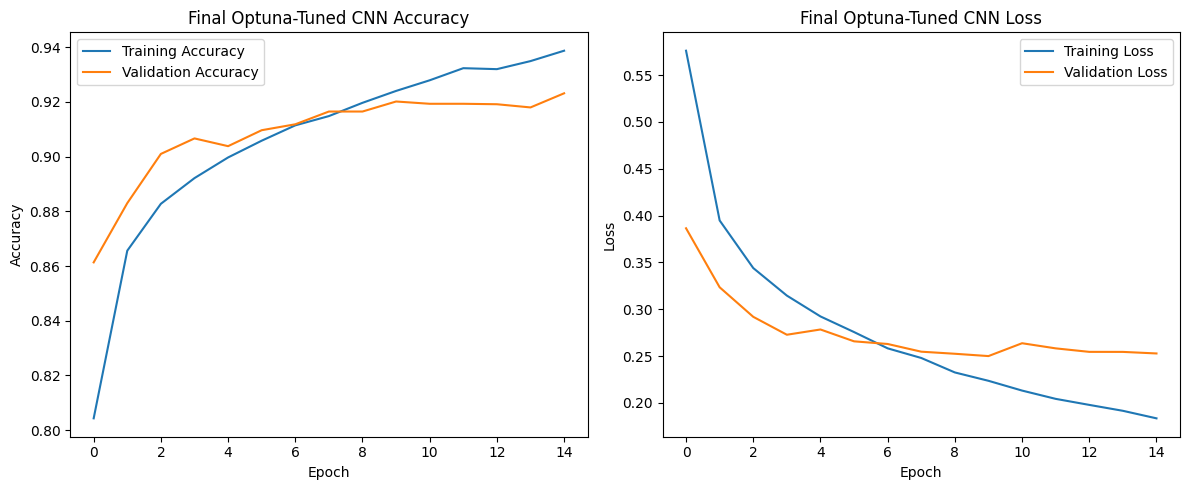

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step

Final Optuna-Tuned CNN Test Evaluation
Accuracy:  0.9077
Precision: 0.9077
Recall:    0.9077
F1 Score:  0.9067


In [18]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

final_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        best_params["filters_1"],
        (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(best_params["l2_rate"])
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        best_params["filters_2"],
        (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(best_params["l2_rate"])
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        best_params["dense_units"],
        activation="relu",
        kernel_regularizer=regularizers.l2(best_params["l2_rate"])
    ),
    layers.Dropout(best_params["dropout_rate"]),

    layers.Dense(10, activation="softmax")
])

final_model.compile(
    optimizer=Adam(learning_rate=best_params["learning_rate"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop_final = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=best_params["batch_size"],
    validation_split=0.1,
    callbacks=[early_stop_final],
    verbose=1
)

plot_training_curves(final_history, "Final Optuna-Tuned CNN")

final_results = evaluate_model(
    final_model,
    X_test,
    y_test,
    "Final Optuna-Tuned CNN"
)

# Final Comparison Table

In [19]:
final_results_df = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Round 1: Dropout",
        "Round 2: Larger CNN",
        "Round 3: BatchNorm",
        "Round 4: L2 + Dropout + EarlyStopping",
        "Round 5: Optuna Final Model"
    ],
    "Accuracy": [
        baseline_results[0],
        dropout_results[0],
        larger_results[0],
        batchnorm_results[0],
        regularized_results[0],
        final_results[0]
    ],
    "Precision": [
        baseline_results[1],
        dropout_results[1],
        larger_results[1],
        batchnorm_results[1],
        regularized_results[1],
        final_results[1]
    ],
    "Recall": [
        baseline_results[2],
        dropout_results[2],
        larger_results[2],
        batchnorm_results[2],
        regularized_results[2],
        final_results[2]
    ],
    "F1 Score": [
        baseline_results[3],
        dropout_results[3],
        larger_results[3],
        batchnorm_results[3],
        regularized_results[3],
        final_results[3]
    ]
})

final_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline CNN,0.9036,0.904637,0.9036,0.901280
1,Round 1: Dropout,0.9052,0.905480,0.9052,0.903622
2,Round 2: Larger CNN,0.9068,0.909428,0.9068,0.905259
3,Round 3: BatchNorm,0.9052,0.905882,0.9052,0.903453
4,Round 4: L2 + Dropout + EarlyStopping,0.9027,0.902365,0.9027,0.901150
5,Round 5: Optuna Final Model,0.9077,0.907680,0.9077,0.906707


The Optuna-tuned CNN achieved the strongest overall performance, reaching a test accuracy of approximately 90.8% and producing the highest precision, recall, and F1 score among all experiments. Unlike the larger CNN model, which showed stronger signs of overfitting, the Optuna model maintained a better balance between predictive performance and generalization. The results demonstrate the value of systematic hyperparameter tuning compared to manual architecture modifications.

# Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


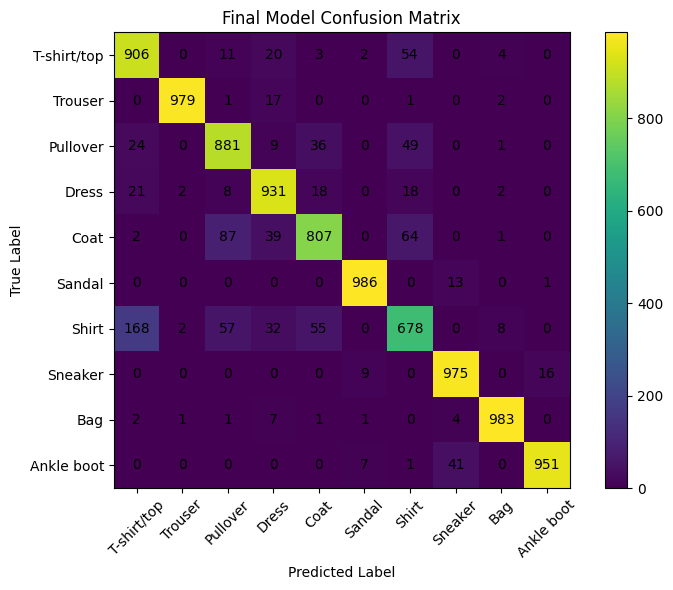

In [20]:
y_pred_prob = final_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(np.arange(10), class_names, rotation=45)
plt.yticks(np.arange(10), class_names)

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

The confusion matrix shows that the final Optuna-tuned CNN classified most Fashion MNIST categories accurately, with strong performance across nearly all classes.

The model performed especially well on:
- Trouser (979 correct predictions)
- Sandal (986 correct predictions)
- Sneaker (975 correct predictions)
- Bag (983 correct predictions)
- Ankle boot (951 correct predictions)

These categories have distinctive visual characteristics, making them easier for the CNN to separate from other clothing items.

The most challenging classes were:
- Shirt (678 correct predictions)
- Coat (807 correct predictions)
- Pullover (881 correct predictions)

Many classification errors occurred between shirts, coats, pullovers, and T-shirts. These categories share similar shapes, sleeves, and overall silhouettes, making them visually more difficult to distinguish.

For example:
- Shirts were frequently misclassified as T-shirts, pullovers, and coats.
- Coats were often confused with pullovers and shirts.
- Pullovers were sometimes predicted as coats or shirts.

Overall, the confusion matrix suggests that the model learned strong visual features for most categories while struggling mainly with clothing classes that have highly similar appearances. This behavior is consistent with the known difficulty of the Fashion MNIST dataset.

# Final Conclusion and Personal Workflow

Across this project, I first built a simple baseline CNN and then improved it through several controlled experiments. I tested dropout, increased model capacity, batch normalization, combined regularization, and finally Optuna hyperparameter tuning.

The final Optuna-tuned CNN performed best overall, achieving a test accuracy of approximately 90.8%. This model also produced the strongest precision, recall, and F1 score. The results showed that the best model was not simply the largest model, but the one that balanced moderate CNN capacity with dropout, light L2 regularization, and an appropriate learning rate.

A major pattern I observed was the tradeoff between model complexity and generalization. The larger CNN improved test accuracy compared to the baseline, but it also showed clearer overfitting in the training curves. Regularization methods helped stabilize training and reduce overfitting, although they did not always improve raw accuracy.

In the future, I would start with a simple baseline model, use training and validation curves to identify overfitting, test one modeling change at a time, and then apply systematic tuning methods such as Optuna to find a stronger final configuration. This workflow helped me understand not only which model performed best, but also why certain modeling choices improved or weakened performance.